# 02 · MAE 训练与遮挡重建评估

本 Notebook 只评价 **MAE 训练任务的出口：被遮挡区域的像素预测**。不使用基因、药物或 embedding 检索标签。请在服务器的 `Python (cellvit)` 内核中运行，代码与训练版本保持一致。

流程：读取训练日志 → 查看更新/溢出记录 → 加载已有 checkpoint → 固定遮挡评估验证集 → 查看各通道指标 → 查看遮挡重建图。

- 输入：六通道图像 `[B,6,512,512]`，像素为 `[0,1]`。
- 训练时 Encoder 默认只看 25% patch；Decoder 预测全部 patch，误差只统计其余 75%。
- 默认目标是 **每个 patch、每个通道内部标准化的像素**。不是原始强度，也不是离散视觉 token 分类。
- 此处只做推理，不更新参数。完整验证集可能耗时；下方可明确选择部分评估。


## 1. 配置运行目录

将 `RUN_DIR` 改为训练命令的 `--output` 目录。也可设置环境变量 `CELLVIT_RUN_DIR`。
默认查看 `latest.pt`；比较最佳重建模型时，将 `CHECKPOINT_NAME` 改成 `best_reconstruction.pt`。
日志查看不依赖 checkpoint；如果训练尚未保存模型，先只运行前半部分。


In [19]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from cellvit.data.streaming_dataset import make_dataloader
from cellvit.evaluate import evaluate_reconstruction
from cellvit.models import MAEConfig, MaskedAutoencoder

PROJECT_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()),
    Path.cwd(),
)
RUN_DIR = Path(
    "/NFS2_home/NFS2_home_3/xkj2006/cell_painting/project/runs/mae_batch2_20epochs"
)
CHECKPOINT_NAME = "latest.pt"
SPLIT = "val"                  # 先验证，方案确定后再改成 test。
MAX_BATCHES = None             # None = 完整评估；32 = 仅前 32 个 batch 的快速预览。
NUM_WORKERS = 0                # Notebook 中从 0 开始；服务器可自行增大。
FORCE_FP32 = False             # 默认沿用训练精度；改动后不直接与 AMP 分数混比。
PREVIEW_WELLS = 1

print("Run directory:", RUN_DIR.resolve())


Run directory: /NFS2_home/NFS2_home_3/xkj2006/cell_painting/project/runs/mae_batch2_20epochs


## 2. 读取日志

`train_loss` 是一组梯度累积样本的平均 loss；验证指标覆盖整份验证集。训练曲线会更抖动。

- `step`：成功更新次数。
- `update_attempts`：包含 AMP 跳过在内的更新尝试次数；学习率和周期保存按此推进。
- `amp_overflow=True`：这次未更新模型，GradScaler 降低缩放系数后继续。
- `val_reconstruction_loss` / `val_masked_mse`：同一项验证 MSE，保留旧字段以兼容旧日志。

只完成短程训练、尚未跑完一轮时，没有验证记录是正常的。下面兼容旧日志；实时读取时只忽略最后一条尚未写完整的记录。


In [2]:
log_path = RUN_DIR / "metrics.jsonl"
records = []
if log_path.exists():
    lines = log_path.read_text(encoding="utf-8").splitlines()
    for index, line in enumerate(lines):
        if not line.strip():
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            if index != len(lines) - 1:
                raise
            print("忽略正在写入的最后一条记录；稍后重新运行本单元格。")
else:
    print("尚无 metrics.jsonl；已有 checkpoint 时可直接运行第 4 节。")

train_df = pd.DataFrame([r for r in records if "train_loss" in r])
val_df = pd.DataFrame([r for r in records if "val_reconstruction_loss" in r])

if not train_df.empty:
    if "update_attempts" not in train_df:
        train_df["update_attempts"] = train_df["step"]
    else:
        train_df["update_attempts"] = train_df["update_attempts"].fillna(train_df["step"])
    display(train_df.tail(5))
if not val_df.empty:
    columns = [c for c in (
        "epoch", "step", "val_reconstruction_loss",
        "val_zero_baseline_mse", "val_reconstruction_skill", "val_wells",
    ) if c in val_df]
    display(val_df[columns].tail(10))
else:
    print("暂无轮末验证记录；第 4 节可以直接评估当前 checkpoint。")


,step,epoch,update_attempts,skipped_updates,amp_overflow,grad_norm,loss_scale_before,loss_scale,batch_in_epoch,train_loss,learning_rate,wells_per_second,peak_gpu_gb
54355,54336,19,54356,20,False,2.842464,65536.0,65536.0,86848,0.642305,3.469484e-12,29.569787,0.708068
54356,54337,19,54357,20,False,0.938065,65536.0,65536.0,86880,0.646102,2.220470e-12,29.569489,0.708068
54357,54338,19,54358,20,False,0.793415,65536.0,65536.0,86912,0.646314,1.249014e-12,29.569259,0.708068
54358,54339,19,54359,20,False,1.690281,65536.0,65536.0,86944,0.642965,5.551175e-13,29.569141,0.708068
54359,54340,19,54360,20,False,1.435331,65536.0,65536.0,86968,0.645949,1.387794e-13,29.569009,0.708068


,epoch,step,val_reconstruction_loss,val_zero_baseline_mse,val_reconstruction_skill,val_wells
10,10,29889,0.677600,0.877655,0.227943,24718
11,11,32606,0.659108,0.877655,0.249013,24718
12,12,35321,0.657986,0.877655,0.250291,24718
13,13,38038,0.649899,0.877655,0.259506,24718
14,14,40755,0.645182,0.877655,0.264880,24718
15,15,43472,0.645030,0.877655,0.265053,24718
16,16,46189,0.640617,0.877655,0.270082,24718
17,17,48907,0.638096,0.877655,0.272954,24718
18,18,51622,0.637000,0.877655,0.274203,24718
19,19,54340,0.636875,0.877655,0.274345,24718


## 3. 训练曲线与重建评分

主误差是隐藏像素的 **Masked MSE**，越低越好。为了方便解释，另外报告：

$$S=1-\frac{\mathrm{MSE}_{model}}{\mathrm{MSE}_{zero}}$$

`MSE_zero` 在完全相同的隐藏位置上计算，基线始终预测 0。在默认标准化目标空间中，0 是局部标准化均值。

- S = 1：隐藏目标重建完全正确。
- S = 0：与全零基线相同。
- S < 0：比基线差。
- S = 0.4：误差相对基线降低 40%，**不是分类准确率 40%**。
- 当全部目标能量接近零时，S 不可定义，输出 `None`，仍报告 MSE。

S 用整份评估数据累计的误差求比值，不先平均各 batch 的百分比。它是相对重建评分，不是绝对原始像素恢复精度。


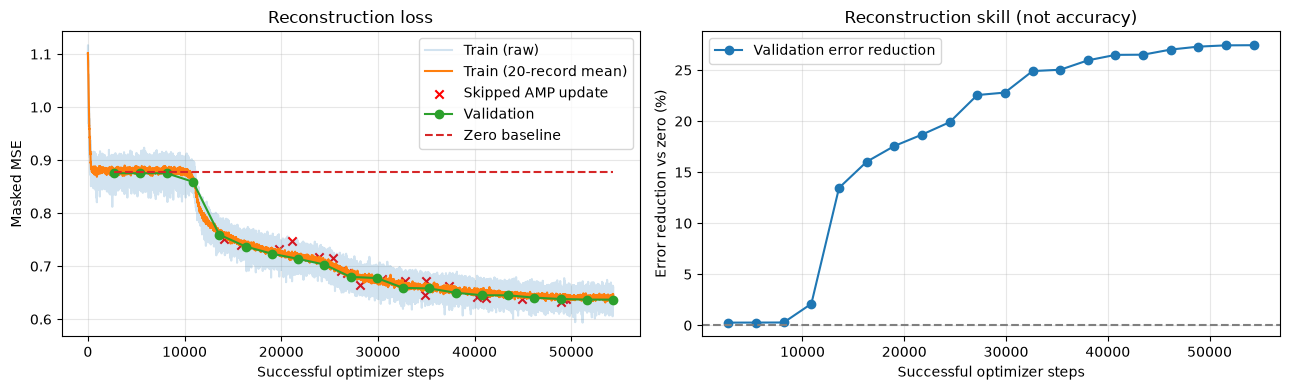

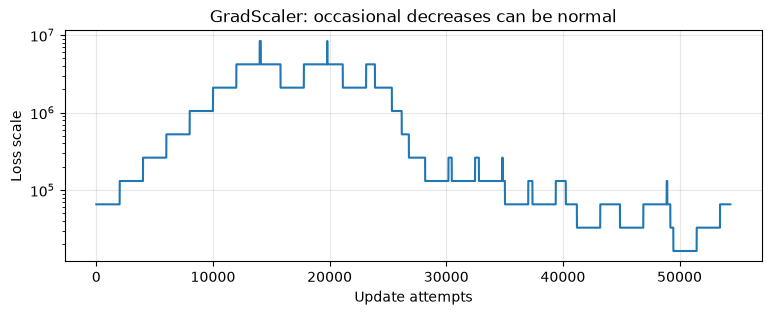

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if not train_df.empty:
    axes[0].plot(train_df["step"], train_df["train_loss"], alpha=0.2, label="Train (raw)")
    axes[0].plot(
        train_df["step"], train_df["train_loss"].rolling(20, min_periods=1).mean(),
        label="Train (20-record mean)",
    )
    if "amp_overflow" in train_df:
        skipped = train_df["amp_overflow"].fillna(False).astype(bool)
        axes[0].scatter(
            train_df.loc[skipped, "step"], train_df.loc[skipped, "train_loss"],
            marker="x", color="red", label="Skipped AMP update",
        )
if not val_df.empty:
    axes[0].plot(
        val_df["step"], val_df["val_reconstruction_loss"], "o-", label="Validation",
    )
    if "val_zero_baseline_mse" in val_df:
        axes[0].plot(
            val_df["step"], val_df["val_zero_baseline_mse"], "--", label="Zero baseline",
        )
    if "val_reconstruction_skill" in val_df:
        axes[1].plot(
            val_df["step"],
            pd.to_numeric(val_df["val_reconstruction_skill"], errors="coerce") * 100,
            "o-", label="Validation error reduction",
        )
axes[0].set(xlabel="Successful optimizer steps", ylabel="Masked MSE", title="Reconstruction loss")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set(xlabel="Successful optimizer steps", ylabel="Error reduction vs zero (%)",
            title="Reconstruction skill (not accuracy)")
for ax in axes:
    ax.grid(alpha=0.3)
    if ax.get_legend_handles_labels()[0]:
        ax.legend()
plt.tight_layout()
plt.show()

if not train_df.empty and "loss_scale" in train_df:
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(train_df["update_attempts"], train_df["loss_scale"])
    ax.set(xlabel="Update attempts", ylabel="Loss scale", yscale="log",
           title="GradScaler: occasional decreases can be normal")
    ax.grid(alpha=0.3)
    plt.show()


## 4. 评估当前 checkpoint

即使没有完成一个 epoch，也可以直接加载已保存的 `latest.pt` 评估。已有旧 checkpoint 也能使用；只运行重建前向，不需要继续训练。

评估默认使用训练时的 batch size、seed + 10000 和精度，与轮末验证一致。对比不同模型时，还应保持样本顺序、mask_ratio、目标标准化方式一致。改变 batch size 会改变固定遮挡的分配。

只加载自己训练得到的可信 checkpoint。MDS 清单必须与 checkpoint 一致。CPU 可运行，但完整评估会很慢。


In [4]:
import hashlib

checkpoint_path = RUN_DIR / CHECKPOINT_NAME
if not checkpoint_path.is_file():
    raise FileNotFoundError(f"尚无 checkpoint：{checkpoint_path}")

print("Loading checkpoint:", checkpoint_path)
state = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
if state.get("format") != "cellvit-spatial-mae-v1":
    raise ValueError("不是本项目的 MAE checkpoint")

MDS_ROOT = Path(os.environ.get("RXRX3_MDS_ROOT", state["run_config"]["mds_root"]))
manifest_bytes = (MDS_ROOT / "manifest.json").read_bytes()
manifest = json.loads(manifest_bytes)
if manifest.get("format") != "rxrx3-core-well-mds-v1" or not manifest.get("complete"):
    raise ValueError("需要完整转换的 MDS")
if hashlib.sha256(manifest_bytes).hexdigest() != state["manifest_sha256"]:
    raise ValueError("MDS 清单与训练 checkpoint 不一致")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MaskedAutoencoder(MAEConfig(**state["model_config"]))
model.load_state_dict(state["model"])
model.to(device).eval()

BATCH_SIZE = state["run_config"]["batch_size"]
DATA_SEED = state["run_config"]["seed"]
MASK_SEED = DATA_SEED + 10_000
USE_AMP = state["run_config"]["amp"] and not FORCE_FP32 and device.type == "cuda"

def new_eval_loader():
    # 每次评估/预览重新创建，避免沿用一个已消耗的 Streaming 迭代器。
    return make_dataloader(
        mds_root=MDS_ROOT, split=SPLIT, batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS, shuffle_seed=DATA_SEED,
    )

print({
    "checkpoint": str(checkpoint_path), "step": state["global_step"],
    "device": str(device), "batch_size": BATCH_SIZE,
    "precision": "amp_fp16" if USE_AMP else "fp32",
    "split": SPLIT, "max_batches": MAX_BATCHES,
})
# 释放不用于推理的优化器状态，保留已加载的 model。
del state


Loading checkpoint: /NFS2_home/NFS2_home_3/xkj2006/cell_painting/project/runs/mae_batch2_20epochs/latest.pt
{'checkpoint': '/NFS2_home/NFS2_home_3/xkj2006/cell_painting/project/runs/mae_batch2_20epochs/latest.pt', 'step': 54340, 'device': 'cuda', 'batch_size': 2, 'precision': 'amp_fp16', 'split': 'val', 'max_batches': None}


In [6]:
print("Preparing evaluation loader...")
eval_loader = new_eval_loader()
report = evaluate_reconstruction(
    model, eval_loader, device, seed=MASK_SEED,
    amp=USE_AMP, max_batches=MAX_BATCHES,
)
del eval_loader

expected = manifest["counts"][SPLIT]
complete = report["wells"] == expected
if MAX_BATCHES is None and not complete:
    raise RuntimeError(f"评估数量不完整：{report['wells']} / {expected}")

report.update({
    "checkpoint": str(checkpoint_path), "split": SPLIT,
    "expected_wells": expected, "complete_split": complete,
    "batch_size": BATCH_SIZE,
})
display(pd.DataFrame([{
    "Masked MSE ↓": report["masked_mse"],
    "Masked RMSE ↓": report["masked_rmse"],
    "Zero baseline MSE": report["zero_baseline_mse"],
    "Error reduction vs zero (%) ↑": (
        100 * report["reconstruction_skill"]
        if report["reconstruction_skill"] is not None else np.nan
    ),
    "Wells": report["wells"],
    "Complete split": complete,
}]))
print("完整评估" if complete else f"部分评估：只评价了 {report['wells']} / {expected} 个 well")
print("Target space:", report["target_space"], "| Precision:", report["precision"])
print(f"Elapsed: {report['elapsed_seconds']:.1f}s | "
      f"Speed: {report['wells_per_second']:.2f} wells/s | "
      f"Loader wait: {report['loader_wait_seconds']:.1f}s")


Evaluation starting: device=cuda, AMP=True, batches=12359. Waiting for data...


Preparing evaluation loader...


Evaluation 1/12359 batches, wells=2, MSE=0.688828, speed=1.62 wells/s, elapsed=1.2s, ETA=15293.7s
Evaluation 50/12359 batches, wells=100, MSE=0.679305, speed=13.00 wells/s, elapsed=7.7s, ETA=1893.8s
Evaluation 100/12359 batches, wells=200, MSE=0.678066, speed=13.74 wells/s, elapsed=14.6s, ETA=1784.5s
Evaluation 150/12359 batches, wells=300, MSE=0.679865, speed=14.33 wells/s, elapsed=20.9s, ETA=1703.5s
Evaluation 200/12359 batches, wells=400, MSE=0.676839, speed=14.46 wells/s, elapsed=27.7s, ETA=1682.0s
Evaluation 250/12359 batches, wells=500, MSE=0.674049, speed=14.52 wells/s, elapsed=34.4s, ETA=1668.5s
Evaluation 300/12359 batches, wells=600, MSE=0.673134, speed=14.51 wells/s, elapsed=41.3s, ETA=1661.9s
Evaluation 350/12359 batches, wells=700, MSE=0.673748, speed=14.71 wells/s, elapsed=47.6s, ETA=1633.2s
Evaluation 400/12359 batches, wells=800, MSE=0.672414, speed=14.84 wells/s, elapsed=53.9s, ETA=1612.0s
Evaluation 450/12359 batches, wells=900, MSE=0.671809, speed=14.90 wells/s, elap

,Masked MSE ↓,Masked RMSE ↓,Zero baseline MSE,Error reduction vs zero (%) ↑,Wells,Complete split
0,0.636875,0.798045,0.877655,27.434465,24718,True


完整评估
Target space: patch_channel_standardized | Precision: amp_fp16
Elapsed: 1734.5s | Speed: 14.25 wells/s | Loader wait: 1501.5s


## 5. 各通道表现

各通道均在隐藏位置上评价。标准化缓解通道亮度尺度差异，但每个通道的结构和可预测性仍然不同。某个通道的评分持续很低时，应结合下一节图像检查。

所有通道加权汇总的总评分不等于各通道评分的简单平均。比较实验时不要混用这两种汇总方法。


,channel,masked_mse,zero_baseline_mse,reconstruction_skill
0,ch1,0.505015,0.799608,0.368421
1,ch2,0.620706,0.909323,0.317397
2,ch3,0.772631,0.911021,0.151906
3,ch4,0.587165,0.872154,0.326765
4,ch5,0.629537,0.830504,0.241982
5,ch6,0.706197,0.943323,0.251373


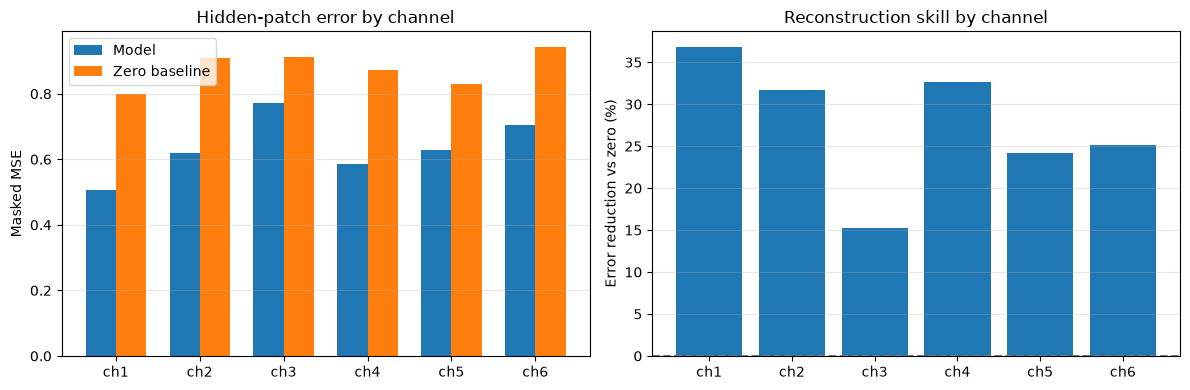

In [7]:
channel_df = pd.DataFrame({
    "channel": [f"ch{i + 1}" for i in range(model.config.in_channels)],
    "masked_mse": report["per_channel_mse"],
    "zero_baseline_mse": report["per_channel_zero_baseline_mse"],
    "reconstruction_skill": report["per_channel_reconstruction_skill"],
})
display(channel_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(channel_df))
axes[0].bar(x - 0.18, channel_df["masked_mse"], width=0.36, label="Model")
axes[0].bar(x + 0.18, channel_df["zero_baseline_mse"], width=0.36, label="Zero baseline")
axes[0].set(ylabel="Masked MSE", title="Hidden-patch error by channel")
axes[0].legend()
axes[1].bar(x, pd.to_numeric(channel_df["reconstruction_skill"], errors="coerce") * 100)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set(ylabel="Error reduction vs zero (%)", title="Reconstruction skill by channel")
for ax in axes:
    ax.set_xticks(x, channel_df["channel"])
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 6. 六通道重建图

这里使用评估集第一批、相同的遮挡种子。每行一个通道：

1. 原图：原始输入 `[0,1]`。
2. 可见输入：灰色区域被遮挡，Encoder 看不到。
3. 真实目标：默认是 patch 内标准化像素，与训练 loss 一致。
4. 补全目标：隐藏区域使用预测，可见区域复制真实目标，仅帮助观察上下文。
5. 绝对误差：只显示隐藏区域。

**第 3、4 列使用相同色阶；指标只计算隐藏部分。** 显示时使用分位数色阶提升可读性，指标计算没有裁剪预测。
这里不使用隐藏区域的真实均值/方差把预测恢复成原始亮度，因此不会把真实强度信息注入预测图。


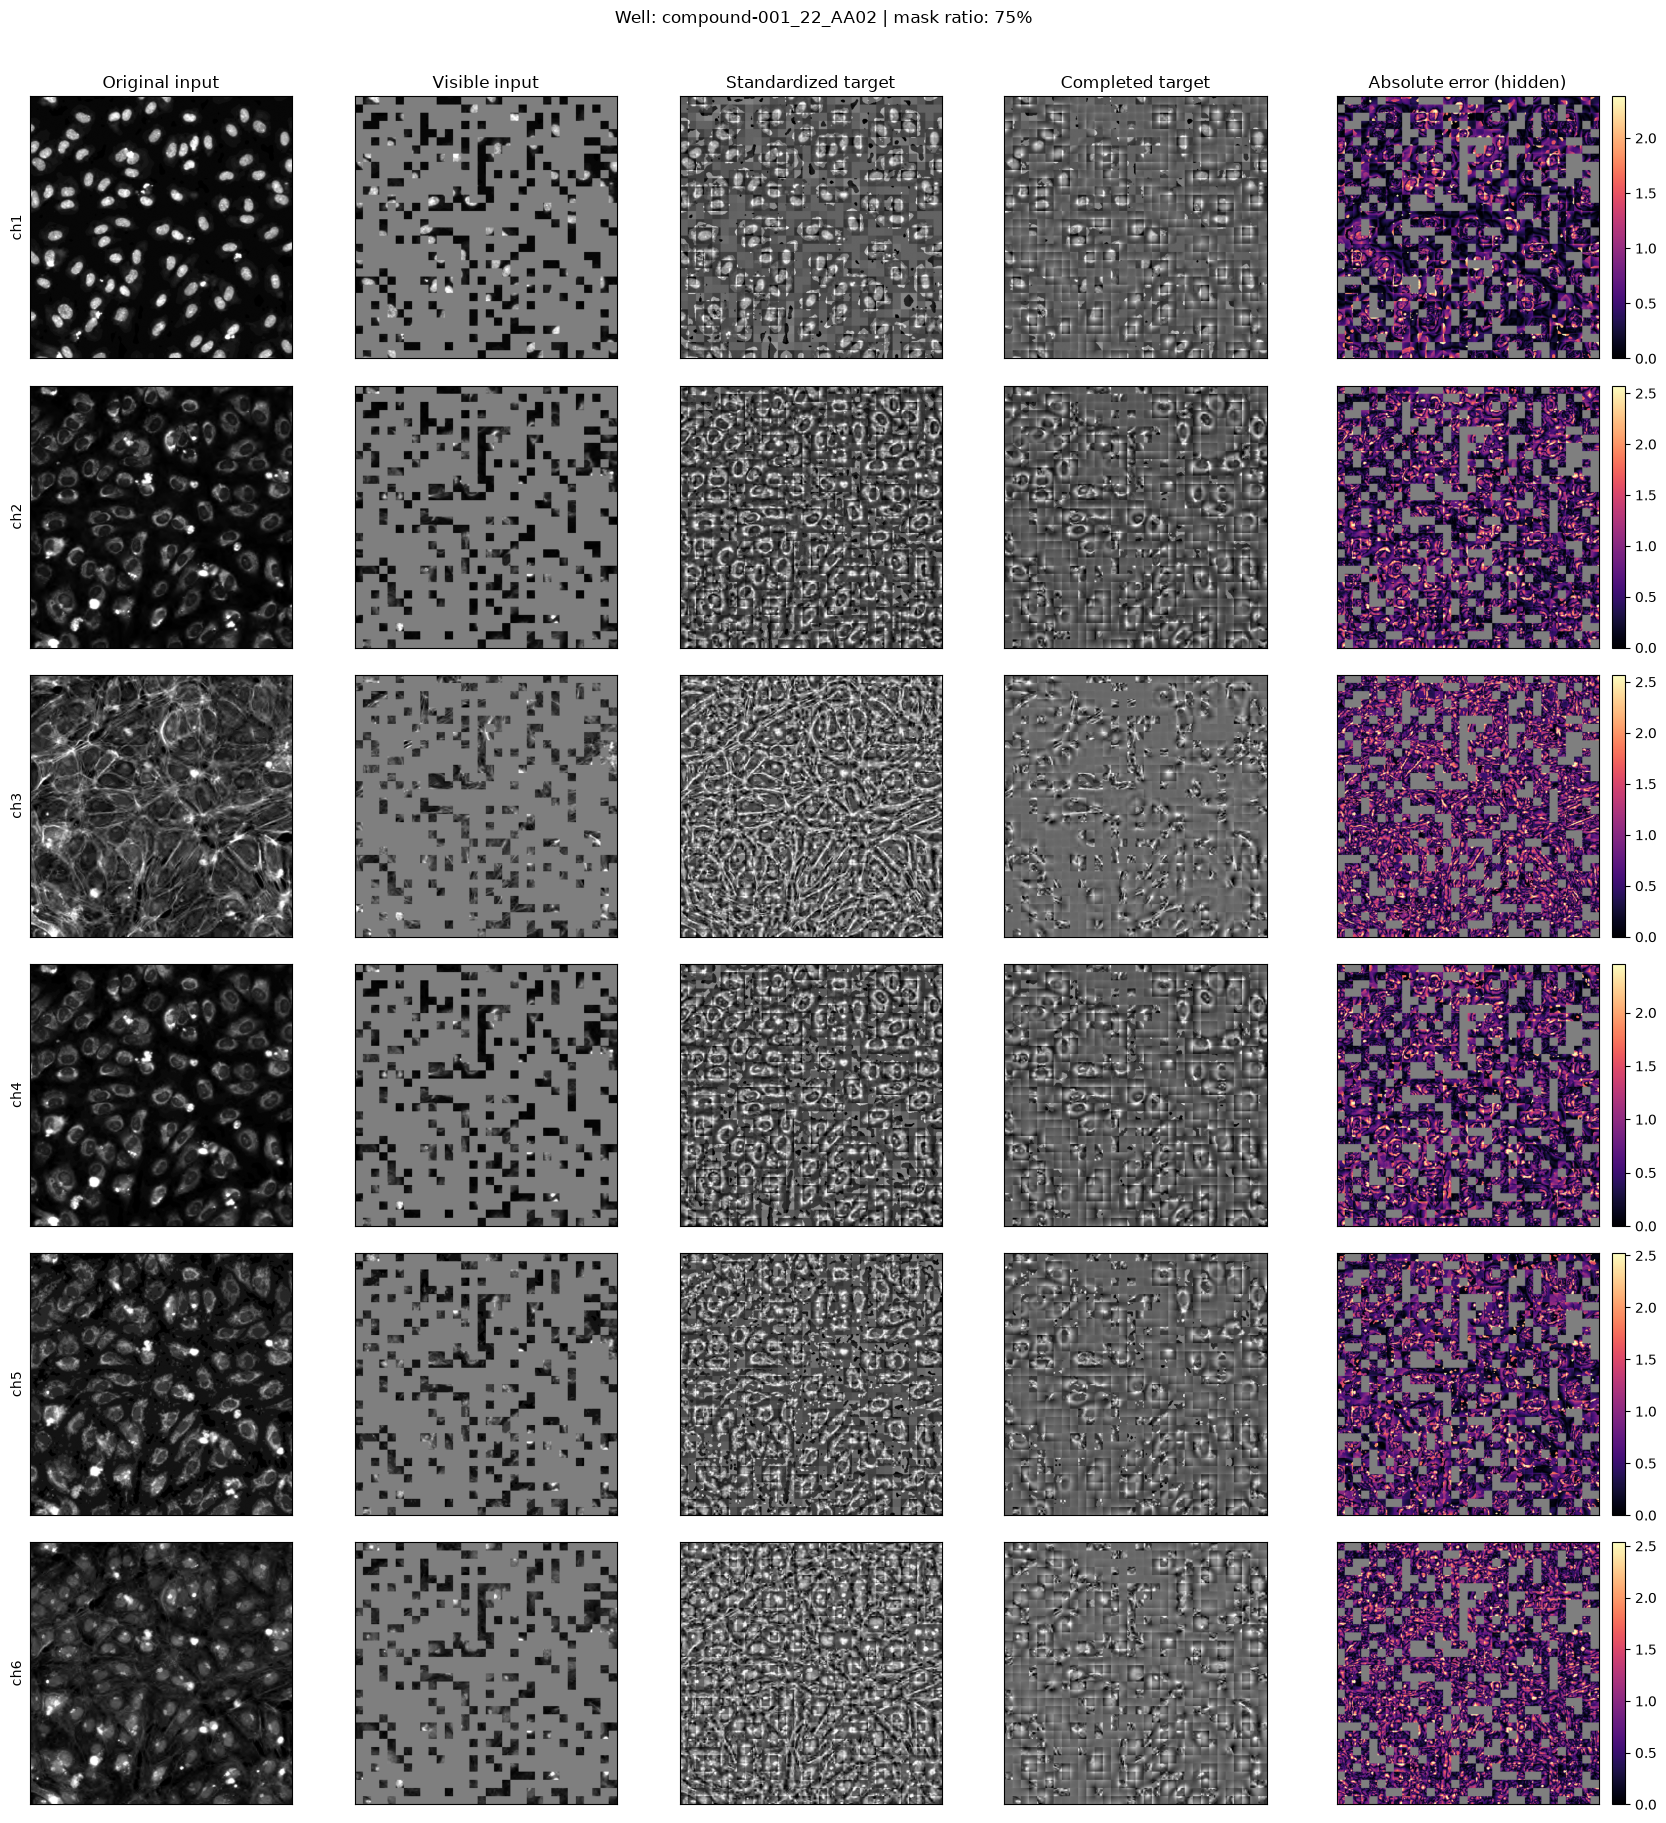

In [8]:
preview_loader = new_eval_loader()
batch = next(iter(preview_loader))
images = batch["image"].to(device)
with torch.inference_mode():
    generator = torch.Generator(device=device).manual_seed(MASK_SEED)
    with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
        output = model(images, generator=generator)
    target_patches = output["target"]
    prediction_patches = output["prediction"].float().reshape_as(target_patches)
    target_images = model.unpatchify(target_patches).cpu().numpy()
    prediction_images = model.unpatchify(prediction_patches).cpu().numpy()
    pixel_mask = model.unpatchify(
        output["mask"][:, :, None, None].expand_as(target_patches)
    ).bool().cpu().numpy()
raw_images = images.cpu().numpy()
well_ids = batch["well_id"]
del preview_loader, images, output, target_patches, prediction_patches

gray = plt.get_cmap("gray").copy()
gray.set_bad("0.5")
heat = plt.get_cmap("magma").copy()
heat.set_bad("0.5")
target_label = "Standardized target" if model.config.norm_pix_loss else "Raw target"

for well_index in range(min(PREVIEW_WELLS, len(raw_images))):
    channels = model.config.in_channels
    fig, axes = plt.subplots(channels, 5, figsize=(17, 3 * channels), squeeze=False)
    for channel in range(channels):
        raw = raw_images[well_index, channel]
        target = target_images[well_index, channel]
        prediction = prediction_images[well_index, channel]
        hidden = pixel_mask[well_index, channel]
        completed = np.where(hidden, prediction, target)
        error = np.abs(prediction - target)
        raw_lo, raw_hi = np.quantile(raw, [0.01, 0.995])
        target_lo, target_hi = np.quantile(target, [0.01, 0.99])
        raw_hi = max(raw_hi, raw_lo + 1e-6)
        target_hi = max(target_hi, target_lo + 1e-6)

        axes[channel, 0].imshow(raw, cmap=gray, vmin=raw_lo, vmax=raw_hi)
        axes[channel, 1].imshow(
            np.ma.masked_where(hidden, raw), cmap=gray, vmin=raw_lo, vmax=raw_hi,
        )
        axes[channel, 2].imshow(target, cmap=gray, vmin=target_lo, vmax=target_hi)
        axes[channel, 3].imshow(completed, cmap=gray, vmin=target_lo, vmax=target_hi)
        heatmap = axes[channel, 4].imshow(
            np.ma.masked_where(~hidden, error), cmap=heat,
            vmin=0, vmax=max(float(np.quantile(error[hidden], 0.99)), 1e-6),
        )
        fig.colorbar(heatmap, ax=axes[channel, 4], fraction=0.046, pad=0.04)
        axes[channel, 0].set_ylabel(f"ch{channel + 1}")
        for ax in axes[channel]:
            ax.set_xticks([])
            ax.set_yticks([])
    for ax, title in zip(axes[0], [
        "Original input", "Visible input", target_label,
        "Completed target", "Absolute error (hidden)",
    ]):
        ax.set_title(title)
    fig.suptitle(f"Well: {well_ids[well_index]} | mask ratio: {model.config.mask_ratio:.0%}", y=1.01)
    plt.tight_layout()
    plt.show()


# Accuracy

In [ ]:
from itertools import islice
from time import perf_counter

import numpy as np
import pandas as pd
import torch
from IPython.display import display


@torch.inference_mode()
def evaluate_mae_metrics(max_batches=None, log_every=100):
    """
    只评价被遮挡区域。

    1. 重建指标：保持模型原来的训练目标空间。
    2. 灰度指标：使用真实 patch 统计量反标准化，
       再转换为 0～255 整数灰度。

    Nearest-5 使用距离预测灰度最近的五个灰度档位，
    不代表模型输出的五个分类候选。
    """
    if max_batches is not None and max_batches < 1:
        raise ValueError("max_batches 必须为正整数或 None。")
    if log_every < 0:
        raise ValueError("log_every 不能为负数。")

    model.eval()
    channels = model.config.in_channels

    # 每个通道分别累计，最后统一计算指标。
    stat_names = [
        "count",
        "squared_error",
        "absolute_error",
        "target_sum",
        "prediction_sum",
        "target_squared_sum",
        "prediction_squared_sum",
        "cross_sum",
        "gray_correct",
        "nearest5_correct",
    ]
    totals = torch.zeros(
        channels,
        len(stat_names),
        dtype=torch.float64,
        device=device,
    )

    wells = 0
    batches = 0
    seen_ids = set()
    started = perf_counter()

    print(
        f"开始评估：split={SPLIT}，"
        f"mask_ratio={model.config.mask_ratio:.0%}，"
        f"max_batches={max_batches}"
    )
    loader = new_eval_loader()

    def sum_per_channel(values):
        # 输入：[隐藏 patch 数, 通道数, patch 内像素数]
        # 输出：[通道数]
        return values.sum(dim=(0, 2), dtype=torch.float64)

    for batch_index, batch in enumerate(islice(loader, max_batches)):
        well_ids = list(batch["well_id"])

        if len(set(well_ids)) != len(well_ids):
            raise RuntimeError("当前 batch 中出现重复 well_id。")
        if seen_ids.intersection(well_ids):
            raise RuntimeError("评估过程中出现重复 well_id。")
        seen_ids.update(well_ids)

        images = batch["image"].to(device, non_blocking=True)

        generator = torch.Generator(device=device).manual_seed(
            MASK_SEED + batch_index
        )

        # 模型前向计算
        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            output = model(images, generator=generator)

        target = output["target"].float()
        prediction = output["prediction"].float().reshape_as(target)
        hidden = output["mask"].bool()

        # --------------------------------------------------
        # 1. 原来的重建指标：保留原有目标空间
        # --------------------------------------------------
        y = target[hidden]
        p = prediction[hidden]

        finite = torch.isfinite(y).all() & torch.isfinite(p).all()
        if not finite.item():
            raise FloatingPointError("目标或预测包含 NaN / Inf。")

        error = p - y

        # 每个通道参与评价的隐藏像素数量
        pixel_count = y.shape[0] * y.shape[2]
        counts = torch.full(
            (channels,),
            pixel_count,
            dtype=torch.float64,
            device=device,
        )

        # --------------------------------------------------
        # 2. 反标准化，恢复到输入像素尺度 [0, 1]
        # --------------------------------------------------
        raw_target = model.patchify(images.float())[hidden]

        if model.config.norm_pix_loss:
            # 使用真实隐藏 patch 的均值、标准差。
            # 与模型 reconstruction_target() 的公式一致。
            patch_mean = raw_target.mean(dim=-1, keepdim=True)
            patch_std = (
                raw_target.var(
                    dim=-1,
                    unbiased=False,
                    keepdim=True,
                ) + 1e-6
            ).sqrt()

            raw_prediction = p * patch_std + patch_mean
        else:
            raw_prediction = p

        # --------------------------------------------------
        # 3. 转为整数灰度，计算严格匹配和邻近五档命中
        # --------------------------------------------------
        true_gray = (
            (raw_target * 255).round().clamp(0, 255).long()
        )
        pred_gray = (
            (raw_prediction * 255).round().clamp(0, 255).long()
        )

        gray_correct = pred_gray == true_gray

        # 常规情况：
        # 预测 128 → 候选 126、127、128、129、130
        #
        # 边界情况仍保留五个合法灰度：
        # 预测 0   → 候选 0、1、2、3、4
        # 预测 255 → 候选 251、252、253、254、255
        lower = (pred_gray - 2).clamp(0, 251)
        nearest5_correct = (
            (true_gray >= lower)
            & (true_gray <= lower + 4)
        )

        # --------------------------------------------------
        # 4. 累计当前 batch 的统计量
        # --------------------------------------------------
        totals += torch.stack([
            counts,
            sum_per_channel(error.square()),
            sum_per_channel(error.abs()),
            sum_per_channel(y),
            sum_per_channel(p),
            sum_per_channel(y.square()),
            sum_per_channel(p.square()),
            sum_per_channel(y * p),
            sum_per_channel(gray_correct),
            sum_per_channel(nearest5_correct),
        ], dim=1)

        wells += len(well_ids)
        batches += 1

        if log_every and (batches == 1 or batches % log_every == 0):
            elapsed = perf_counter() - started
            print(
                f"已评估 {batches} batches | "
                f"{wells} wells | "
                f"{wells / max(elapsed, 1e-6):.1f} wells/s"
            )

    del loader

    # ------------------------------------------------------
    # 5. 循环结束后，计算最终指标
    # ------------------------------------------------------
    if wells == 0:
        raise RuntimeError("没有读取到评估样本。")

    expected_wells = manifest["counts"][SPLIT]
    complete = wells == expected_wells

    if max_batches is None and not complete:
        raise RuntimeError(
            f"评估数量不完整：{wells} / {expected_wells}"
        )

    channel_totals = totals.cpu().numpy()
    elapsed = perf_counter() - started

    if not np.isfinite(channel_totals).all():
        raise FloatingPointError("累计统计量出现 NaN / Inf。")

    # 第一行合并所有通道，后面保留各通道。
    combined = np.vstack([
        channel_totals.sum(axis=0),
        channel_totals,
    ])
    scopes = ["Overall"] + [
        f"ch{i + 1}" for i in range(channels)
    ]

    def safe_divide(numerator, denominator):
        if denominator <= 1e-12:
            return np.nan
        return numerator / denominator

    rows = []

    for scope, values in zip(scopes, combined):
        (
            n,
            squared_error,
            absolute_error,
            target_sum,
            prediction_sum,
            target_squared_sum,
            prediction_squared_sum,
            cross_sum,
            total_correct,
            total_nearest5_correct,
        ) = values

        mse = squared_error / n
        zero_mse = target_squared_sum / n

        mean_y = target_sum / n
        mean_p = prediction_sum / n

        variance_y = max(
            target_squared_sum / n - mean_y**2, 0.0
        )
        variance_p = max(
            prediction_squared_sum / n - mean_p**2, 0.0
        )
        covariance = cross_sum / n - mean_y * mean_p

        pearson = safe_divide(
            covariance,
            np.sqrt(variance_y * variance_p),
        )

        # 先累计正确数与像素数，再计算比例。
        gray_acc = 100 * total_correct / n
        nearest5_acc = 100 * total_nearest5_correct / n

        rows.append({
            "scope": scope,
            "MSE": mse,
            "RMSE": np.sqrt(mse),
            "MAE": absolute_error / n,
            "Zero_baseline_MSE": zero_mse,
            "Reconstruction_skill_%": (
                100 * (1 - safe_divide(mse, zero_mse))
            ),
            "R2": 1 - safe_divide(mse, variance_y),
            "Pearson": np.clip(pearson, -1, 1),
            "Gray_Acc_%": gray_acc,
            "Nearest5_Gray_Acc_%": nearest5_acc,
        })

    metrics = pd.DataFrame(rows).set_index("scope")

    metadata = {
        "checkpoint": str(checkpoint_path),
        "split": SPLIT,
        "wells": wells,
        "expected_wells": expected_wells,
        "complete_split": complete,
        "batches": batches,
        "mask_ratio": model.config.mask_ratio,
        "mask_seed": MASK_SEED,
        "batch_size": BATCH_SIZE,
        "target_space": (
            "patch_channel_standardized"
            if model.config.norm_pix_loss
            else "raw_0_1"
        ),
        "gray_denormalization": (
            "uses_true_hidden_patch_mean_and_std"
            if model.config.norm_pix_loss
            else "not_needed"
        ),
        "gray_quantization": "round_and_clip_to_uint8",
        "precision": "amp_fp16" if USE_AMP else "fp32",
        "elapsed_seconds": elapsed,
        "wells_per_second": wells / max(elapsed, 1e-6),
    }

    print(
        f"评估完成：{wells} wells，耗时 {elapsed:.1f}s，"
        f"{'完整评估' if complete else '部分评估'}"
    )

    return metrics, metadata


# None：完整评估；32：仅前 32 个 batch 的快速预览。
metrics_df, evaluation_info = evaluate_mae_metrics(
    max_batches=None,
    log_every=100,
)

print("\n评估信息：")
display(pd.Series(evaluation_info, name="value").to_frame())

print("\n整体与各通道指标：")
display(metrics_df.T.round(4))

开始评估：split=val，mask_ratio=75%，max_batches=None
已评估 1 batches | 2 wells | 10.4 wells/s
已评估 100 batches | 200 wells | 13.1 wells/s
已评估 200 batches | 400 wells | 13.2 wells/s
已评估 300 batches | 600 wells | 13.2 wells/s
已评估 400 batches | 800 wells | 13.3 wells/s
已评估 500 batches | 1000 wells | 13.3 wells/s
已评估 600 batches | 1200 wells | 13.2 wells/s
已评估 700 batches | 1400 wells | 13.4 wells/s
已评估 800 batches | 1600 wells | 13.3 wells/s
已评估 900 batches | 1800 wells | 13.4 wells/s
已评估 1000 batches | 2000 wells | 13.5 wells/s
已评估 1100 batches | 2200 wells | 13.5 wells/s
已评估 1200 batches | 2400 wells | 13.6 wells/s
已评估 1300 batches | 2600 wells | 13.6 wells/s
已评估 1400 batches | 2800 wells | 13.6 wells/s
已评估 1500 batches | 3000 wells | 13.6 wells/s
已评估 1600 batches | 3200 wells | 13.6 wells/s
已评估 1700 batches | 3400 wells | 13.7 wells/s
已评估 1800 batches | 3600 wells | 13.7 wells/s
已评估 1900 batches | 3800 wells | 13.8 wells/s
已评估 2000 batches | 4000 wells | 13.8 wells/s
已评估 2100 batches | 4200 wel

,value
checkpoint,/NFS2_home/NFS2_home_3/xkj2006/cell_painting/p...
split,val
wells,24718
expected_wells,24718
complete_split,True
batches,12359
mask_ratio,0.75
mask_seed,12026
batch_size,2
target_space,patch_channel_standardized



整体与各通道指标：


scope,Overall,ch1,ch2,ch3,ch4,ch5,ch6
MSE,0.6369,0.5050,0.6207,0.7726,0.5872,0.6295,0.7062
RMSE,0.7980,0.7106,0.7878,0.8790,0.7663,0.7934,0.8404
MAE,0.5831,0.4962,0.5735,0.6711,0.5580,0.5730,0.6271
Zero_baseline_MSE,0.8777,0.7996,0.9093,0.9110,0.8722,0.8305,0.9433
Reconstruction_skill_%,27.4345,36.8421,31.7397,15.1906,32.6765,24.1982,25.1373
R2,0.2743,0.3684,0.3174,0.1519,0.3268,0.2420,0.2514
Pearson,0.5238,0.6070,0.5634,0.3898,0.5716,0.4919,0.5014
Gray_Acc_%,37.8974,50.4107,29.6452,31.8970,38.5891,50.6501,26.1925
Nearest5_Gray_Acc_%,78.6409,81.1033,63.2567,82.5979,79.2332,92.8102,72.8441


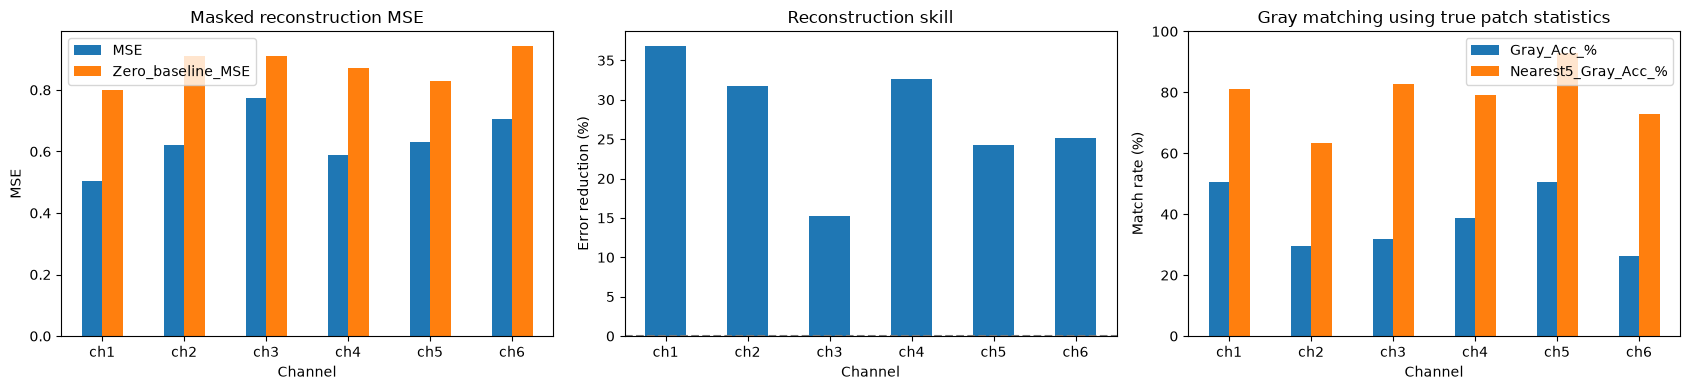

In [12]:
import matplotlib.pyplot as plt

channel_metrics = metrics_df.drop(index="Overall")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

channel_metrics[
    ["MSE", "Zero_baseline_MSE"]
].plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Masked reconstruction MSE")
axes[0].set_ylabel("MSE")

channel_metrics[
    "Reconstruction_skill_%"
].plot.bar(ax=axes[1], rot=0)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("Reconstruction skill")
axes[1].set_ylabel("Error reduction (%)")

channel_metrics[
    ["Gray_Acc_%", "Nearest5_Gray_Acc_%"]
].plot.bar(ax=axes[2], rot=0)
axes[2].set_title("Gray matching using true patch statistics")
axes[2].set_ylabel("Match rate (%)")
axes[2].set_ylim(0, 100)

for ax in axes:
    ax.set_xlabel("Channel")

plt.tight_layout()
plt.show()

# 模型结构

## 7. 如何得出结论

报告模板：

> 在固定验证集、75% 空间遮挡、固定 seed、相同 batch size 和精度下，checkpoint 的 masked MSE 为 **实际值**，全零基线 MSE 为 **实际值**，相对基线误差降低 **实际百分比**。覆盖 **实际 well 数**；目标空间为 patch/通道标准化像素。

- 不把 `1 - MSE` 称为准确率，也不把 normalized MSE 当成原始像素的 PSNR。
- `best_reconstruction.pt` 是完整验证集 MSE 最低的已评估模型；旧 checkpoint 恢复后从新评估开始比较。
- 如需更稳健的最终数字，可分别用几个固定 seed 完整评估，再报告均值和波动；模型之间使用同一组种子。
- 若 AMP 推理本身出现非有限预测，应停止并定位；`FORCE_FP32=True` 可辅助排查，但需标记精度变化。
- Notebook 的图是样本检查；完整验证集指标才是重建任务的总体评价。


In [22]:
from pathlib import Path

import torch

from cellvit.models import MAEConfig, MaskedAutoencoder


CHECKPOINT_PATH = Path(
    "/NFS2_home/NFS2_home_3/xkj2006/cell_painting/project/"
    "runs/mae_batch2_20epochs/best_reconstruction.pt"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
)

config = MAEConfig(**checkpoint["model_config"])
model = MaskedAutoencoder(config)

# 兼容不同 checkpoint 的模型权重字段
if "model" in checkpoint:
    model.load_state_dict(checkpoint["model"])
elif "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    raise KeyError(
        "Checkpoint 中没有找到 'model' 或 'model_state_dict'"
    )

model = model.to(device).eval()

print("Device:", device)
print("Checkpoint:", CHECKPOINT_PATH)
print("Model config:", config)

/tmp/ipykernel_22345/3115313132.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Device: cuda
Checkpoint: /NFS2_home/NFS2_home_3/xkj2006/cell_painting/project/runs/mae_batch2_20epochs/best_reconstruction.pt
Model config: MAEConfig(image_size=512, patch_size=16, in_channels=6, encoder_dim=384, encoder_depth=12, encoder_heads=6, decoder_dim=192, decoder_depth=4, decoder_heads=6, mlp_ratio=4.0, mask_ratio=0.75, norm_pix_loss=True)


In [26]:
import torch
from torchinfo import summary


class MAESummaryWrapper(torch.nn.Module):
    """
    torchinfo 专用包装器。

    原始 MAE 返回：
        {
            "loss": ...,
            "prediction": ...,
            "mask": ...,
            "target": ...
        }

    torchinfo 只需要一个明确的输出张量，
    因此这里返回 prediction。
    """

    def __init__(self, mae):
        super().__init__()
        self.mae = mae

    def forward(self, images):
        output = self.mae(images)
        return output["prediction"]


summary_model = MAESummaryWrapper(model).to(device).eval()

# 本项目模型输入：
# batch_size = 2
# channels   = 6
# height     = 512
# width      = 512
example_images = torch.zeros(
    2,
    6,
    512,
    512,
    dtype=torch.float32,
    device=device,
)

with torch.inference_mode():
    report = summary(
        summary_model,
        input_data=example_images,
        depth=5,
        col_names=(
            "input_size",
            "output_size",
            "num_params",
            "trainable",
        ),
        row_settings=("var_names",),
        mode="eval",
        verbose=0,
    )

print(report)

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
MAESummaryWrapper (MAESummaryWrapper)    [2, 6, 512, 512]          [2, 1024, 1536]           --                        True
├─MaskedAutoencoder (mae)                [2, 6, 512, 512]          [2, 1024, 6, 256]         590,016                   True
│    └─Conv2d (patch_embed)              [2, 6, 512, 512]          [2, 384, 32, 32]          590,208                   True
│    └─ModuleList (encoder_blocks)       --                        --                        --                        True
│    │    └─TransformerBlock (0)         [2, 256, 384]             [2, 256, 384]             --                        True
│    │    │    └─LayerNorm (norm1)       [2, 256, 384]             [2, 256, 384]             768                       True
│    │    │    └─Linear (qkv)            [2, 256, 384]             [2, 256, 1152]            443,520                   True
│  